In [1]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/parkinsons/analysis')


In [34]:
import os
from load_data.load_npz import load_spikedata
from analysis.position_sd import get_neuron_positions
from analysis.firing_sd import mean_firing_rates
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sd24578_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24578_D49-6.zip')
sd24578_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24578_D60+6.zip')
sd24481_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24481_D49-6.zip')
sd24481_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24481_D60+6.zip')

In [4]:
acg24481_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24481_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/acg.npz'
fc24481_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24481_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/func_pairs.npz'
acg24578_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24578_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/acg.npz'
fc24578_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24578_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/func_pairs.npz'
acg24481_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/acg.npz'
fc24481_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/func_pairs.npz'
acg24578_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/acg.npz' 
fc24578_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/func_pairs.npz'

In [5]:
acg24481_49 = np.load(acg24481_49_path, allow_pickle=True)
fc24481_49 = np.load(fc24481_49_path, allow_pickle=True)
acg24578_49 = np.load(acg24578_49_path, allow_pickle=True)
fc24578_49 = np.load(fc24578_49_path, allow_pickle=True)
acg24481_60 = np.load(acg24481_60_path, allow_pickle=True)
fc24481_60 = np.load(fc24481_60_path, allow_pickle=True)
acg24578_60 = np.load(acg24578_60_path, allow_pickle=True)
fc24578_60 = np.load(fc24578_60_path, allow_pickle=True)


In [6]:
ac24481_49 = acg24481_49['acg_dict'].item()
ac24481_60 = acg24481_60['acg_dict'].item()
ac24578_49 = acg24578_49['acg_dict'].item()
ac24578_60 = acg24578_60['acg_dict'].item()

In [7]:
fp24481_49 = fc24481_49['func_pairs'].item()
fp24481_60 = fc24481_60['func_pairs'].item()
fp24578_49 = fc24578_49['func_pairs'].item()
fp24578_60 = fc24578_60['func_pairs'].item()


In [23]:
def sorted_transmission_dict(func_pairs, output_artifact=False):
    """
    Create a sorted dictionary of functional pairs (keys are pairs, values are p_fast),
    and also return dictionaries with only nonnegative values and, optionally,
    only the negative (artifact) values.
    
    Parameters:
      func_pairs (dict): Functional pairs with each value containing 'p_fast'.
      output_artifact (bool): If True, also return a dictionary with only negative p_fast values.
      
    Returns:
      tuple: (full_dict, positive_dict) or (full_dict, positive_dict, artifact_dict)
        - full_dict: All pairs sorted in ascending order of p_fast.
        - positive_dict: Only pairs with p_fast >= 0.
        - artifact_dict: Only pairs with negative p_fast (if output_artifact is True).
    """
    # Create a list of (pair, p_fast) items from func_pairs.
    pair_p_list = [(pair, info['p_fast']) for pair, info in func_pairs.items()]
    # Sort by p_fast in ascending order.
    pair_p_list.sort(key=lambda x: x[1])
    
    full_dict = {pair: p for pair, p in pair_p_list}
    positive_dict = {pair: p for pair, p in pair_p_list if p > 0}
    if output_artifact:
        artifact_dict = {pair: p for pair, p in pair_p_list if p < 0}
        return full_dict, positive_dict, artifact_dict
    else:
        return full_dict, positive_dict

def subset_sorted_dict(sorted_dict, x):
    """
    Return a subset of the sorted dictionary containing only the first x items.
    
    Parameters:
      sorted_dict (dict): A dictionary sorted by the desired criterion (order preserved).
      x (int): The number of items to include.
      
    Returns:
      dict: A new dictionary with only the first x items.
    """
    # Use list slicing on the keys.
    keys_subset = list(sorted_dict.keys())[:x]
    return {k: sorted_dict[k] for k in keys_subset}

In [24]:
sorted_fp24481_49, cleaned_fp24481_49 = sorted_transmission_dict(fp24481_49, output_artifact=False)
sorted_fp24481_60, cleaned_fp24481_60 = sorted_transmission_dict(fp24481_60, output_artifact=False)
sorted_fp24578_49, cleaned_fp24578_49 = sorted_transmission_dict(fp24578_49, output_artifact=False)
sorted_fp24578_60, cleaned_fp24578_60 = sorted_transmission_dict(fp24578_60, output_artifact=False)

In [33]:
def filter_by_latency(func_pairs, min_latency=0.3, max_latency=8.0):
    """
    Remove pairs whose latency is below min_latency or above max_latency.
    """
    filtered = {}
    for pair, info in func_pairs.items():
        lat = info['latency']
        if lat >= min_latency and lat <= max_latency:
            filtered[pair] = info
    return filtered

In [32]:
subset_24481_49= subset_sorted_dict(cleaned_fp24481_49, 10)
subset_24481_60= subset_sorted_dict(cleaned_fp24481_60, 10)
subset_24578_49= subset_sorted_dict(cleaned_fp24578_49, 10)
subset_24578_60= subset_sorted_dict(cleaned_fp24578_60, 10)

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_pair_footprint_and_ccg(sd, pair, ccg_directory, output_path=None):
    """
    Create a figure with two subplots for a given neuron pair.
      Left: Plot the spatial positions (footprints) for the two neurons in the pair.
            The sender neuron is plotted in red and the receiver in blue. Their
            average firing rates (in Hz) are included in the legend.
            A connectivity arrow (using the same style as the functional connectivity
            map) is drawn between the two neurons.
      Right: Load and display the CCg image for the pair from the provided directory.
             The image is assumed to be named "ccg_unit_{sender}_{receiver}.png".
    
    Parameters:
      sd: SpikeData object (must provide get_neuron_positions and mean_firing_rates).
      pair (tuple): A tuple (sender, receiver) indicating the two neuron indices.
      ccg_directory (str): Directory path where CCg images are stored.
      output_path (str, optional): If provided, the figure is saved to this directory
                                   (with a filename based on the pair). Otherwise, the figure is shown.
    
    Returns:
      matplotlib.figure.Figure: The generated figure.
    """
    # Get neuron positions and firing rates.
    positions = get_neuron_positions(sd)   # shape (N,2)
    firing_rates = mean_firing_rates(sd)     # array of average firing rates in Hz
    
    sender, receiver = pair
    pos_sender = positions[sender]
    pos_receiver = positions[receiver]
    rate_sender = firing_rates[sender]
    rate_receiver = firing_rates[receiver]
    
    # Construct the expected filename for the CCg image.
    ccg_image_filename = f"ccg_unit_{sender}_{receiver}.png"
    ccg_image_path = os.path.join(ccg_directory, ccg_image_filename)
    
    # Create figure with two subplots.
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    # Left subplot: Spatial footprints.
    # Plot the two neurons.
    axs[0].scatter(pos_sender[0], pos_sender[1], color='red', s=100, 
                   label=f"Sender: {rate_sender:.1f} Hz")
    axs[0].scatter(pos_receiver[0], pos_receiver[1], color='blue', s=100, 
                   label=f"Receiver: {rate_receiver:.1f} Hz")
    # Draw a connectivity arrow between the two neurons.
    arrowprops = dict(arrowstyle="<|-", color="gray", lw=2, alpha=0.7)
    axs[0].annotate("", xy=pos_receiver, xytext=pos_sender, arrowprops=arrowprops)
    
    axs[0].set_title("Pair Footprint")
    axs[0].set_xlabel("X Position (um)")
    axs[0].set_ylabel("Y Position (um)")
    axs[0].legend(loc='best')
    
    # Right subplot: CCg image.
    if os.path.exists(ccg_image_path):
        ccg_img = plt.imread(ccg_image_path)
        axs[1].imshow(ccg_img)
        axs[1].axis('off')
        axs[1].set_title("CCG")
    else:
        axs[1].text(0.5, 0.5, "CCG image not found", 
                    horizontalalignment='center', verticalalignment='center')
        axs[1].axis('off')
        axs[1].set_title("CCG")
    
    plt.suptitle(f"Pair {pair}: Sender (red) vs. Receiver (blue)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    if output_path:
        os.makedirs(output_path, exist_ok=True)
        filename = f"pair_{sender}_{receiver}.png"
        save_filepath = os.path.join(output_path, filename)
        fig.savefig(save_filepath)
        plt.close(fig)
    else:
        plt.show()
    
    return fig

def plot_all_pairs_footprint_and_ccg(sd, sorted_pairs, ccg_directory, output_path=None):
    """
    Loop over a list of neuron pairs and generate the footprint+CCG combined plot for each.
    
    Parameters:
      sd: SpikeData object.
      sorted_pairs: Iterable of neuron pair tuples (e.g., from a sorted dictionary).
      ccg_directory (str): Directory path containing CCg images.
      output_path (str, optional): If provided, each figure is saved to this directory.
                                   Otherwise, figures are shown interactively.
    """
    for pair in sorted_pairs:
        fig = plot_pair_footprint_and_ccg(sd, pair, ccg_directory, output_path=output_path)
        plt.close(fig)

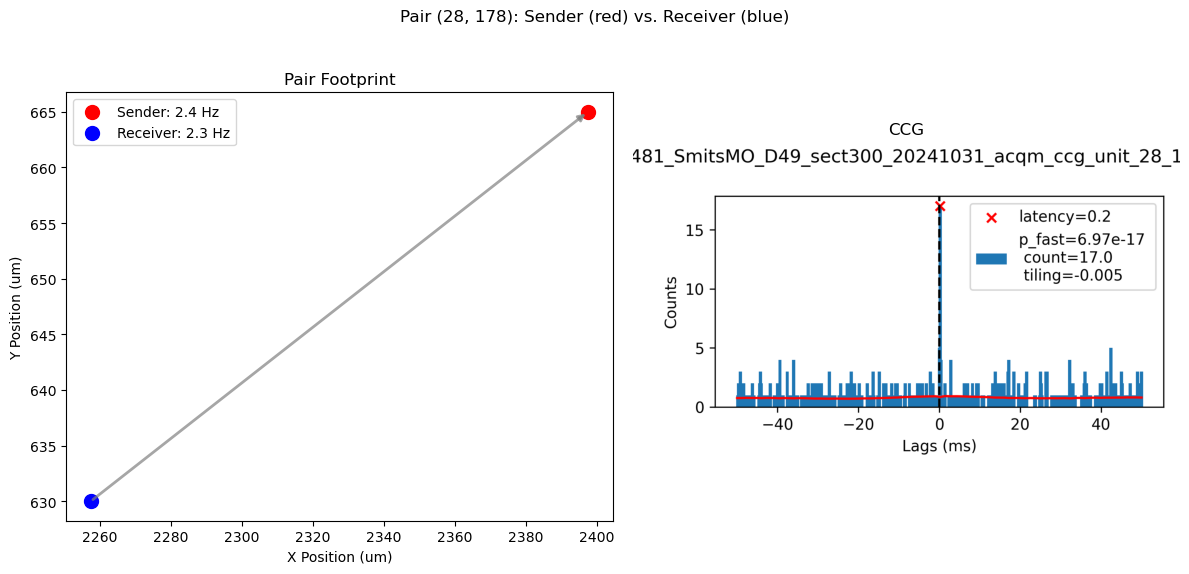

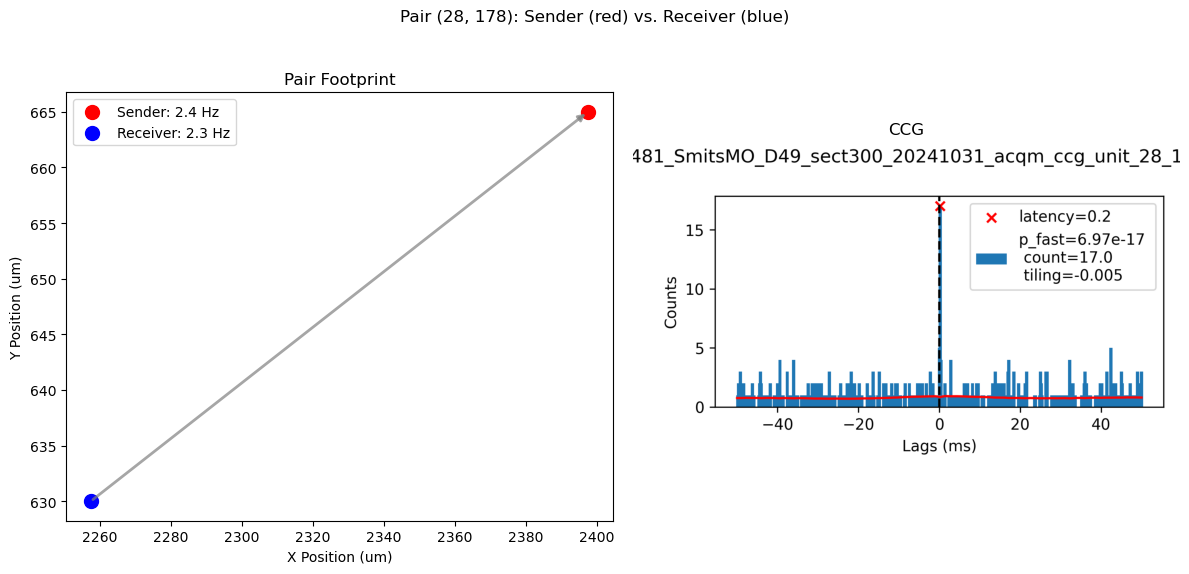

In [31]:
plot_pair_footprint_and_ccg(sd24481_49, (28, 178), '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24481_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg')

In [28]:
plot_all_pairs_footprint_and_ccg(sd24481_49, subset_24481_49, '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24481_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg/', '/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/footprint-ccg/d49/24481/')
plot_all_pairs_footprint_and_ccg(sd24481_60, subset_24481_60, '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg/', '/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/footprint-ccg/d60/24481/')
plot_all_pairs_footprint_and_ccg(sd24578_49, subset_24578_49, '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24578_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg/', '/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/footprint-ccg/d49/24578/')
plot_all_pairs_footprint_and_ccg(sd24578_60, subset_24578_60, '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg/', '/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/footprint-ccg/d60/24578/')